In [19]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [27]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

class KMeans:
    def __init__(self, K=5, max_iters=100, plot_steps=False):
        self.K = K
        self.max_iters = max_iters
        self.plot_steps = plot_steps
        
        # Danh sách các chỉ số mẫu cho mỗi cụm (each cluster)
        self.clusters = [[] for _ in range(self.K)]
        # Các tâm (vector đặc trưng trung bình) cho mỗi cụm
        self.centroids = []
        
    def _closest_centroid(self, sample, centroids):
        """Trái tim logic của toàn bộ thuật toán
        Giải quyết câu hỏi trong các K cụm ngoài kia thì k (centroid) nào gần x (data) hiện tại nhất
        
        Tạo ra các Ranh giới quyết định Decision Boundaries
        """
        # distance of the current sample to each centroid
        distances = [euclidean_distance(sample, point) for point in centroids]
        # list comprehension sử dụng hàm euclidean_distance
        
        closest_index = np.argmin(distances) # quét qua list distances và chỉ ra index min
        return closest_index
        
    def _create_clusters(self, centroids):
        """Dữ liệu X và K (centroids) đứng ở các vị trí khác nhau.
        Nhiệm vụ của hàm này là xếp từng x in X (data) vào nhóm của k in K (centroid) gần nhất
        
        Thực hiện một khái niệm toán học gọi là Voronoi Partition (Phân hoạch Voronoi)
        """
        # Gán các mẫu cho các tâm cụm gần nhất để tạo thành các cụm (hoặc nhóm của tâm cụm đó)
        clusters = [[] for _ in range(self.K)]
        
        # idx: index
        # sample: feature của x đó (ví dụ bộ màu RGB của một pixel)
        for idx, sample in enumerate(self.X):
            # dùng thước đo khoảng cách euclidean xem x (data) này gần k (centroid) nào nhất
            centroid_idx = self._closest_centroid(sample, centroids)
            clusters[centroid_idx].append(idx)
        return clusters
    
    def _get_cluster_labels(self, clusters):
        """Xuất kết quả
        Sau khi các điểm x (data) đã tìm được k (nhóm) thông qua các phép tính toán,
        Hàm này sẽ tổng kết thành một danh sách báo cáo.
        """
        # each sample will get the label of the cluster it was assigned to
        labels = np.empty(self.n_samples)
        
        for cluster_idx, cluster in enumerate(clusters):
            for sample_index in cluster:
                labels[sample_index] = cluster_idx
        return labels
    
    def _get_centroids(self, clusters):
        """Sau khi chia nhóm xong -> xác định xem trung tâm của nhóm đó thực sự nằm ở đâu
        Điểm cách đều tất cả các điểm còn lại, 
        Đây là hàm quan trọng nhất để giúp thuật toán K-Means "thông minh" hơn sau mỗi epoch
        """
        # assign mean value of clusters to centroids
        centroids = np.zeros((self.K, self.n_features))
        
        for cluster_idx, cluester in enumerate(clusters):
            cluster_mean = np.mean(self.X[cluester], axis=0)    # phép tính trung bình cộng
            centroids[cluster_idx] = cluster_mean
        return centroids
    
    def _is_converged(self, centroid_old, centroids):
        """ Nút dừng """
        # distances between each old and new controids, for all centroids
        distances = [euclidean_distance(centroid_old[i], centroids[i]) for i in range(self.K)]
        return sum(distances) == 0
        
    def predict(self, X):
        self.X = X
        self.n_samples, self.n_features = X.shape
        
        # Khởi tạo các cụm k ngẫu nhiên giống thuật toán KNN
        random_sample_idxs = np.random.choice(self.n_samples, self.K, replace=False)
        self.centroids = [self.X[idx] for idx in random_sample_idxs]
        
        # Optimize Clusters
        for _ in range(self.max_iters):
            
            # Assin samples to closest centroids (create clusters)
            # gán các mẫu vào các tâm cụm gần nhất (Tạo các cụm) -> gán nhóm (Assign)
            self.clusters = self._create_clusters(self.centroids)
            
            if self.plot_steps:
                self.plot()
                
            # Calculate new centroids from the clusters -> Update
            centroids_old = self.centroids
            self.centroids = self._get_centroids(self.clusters)
            
            # check if clusters have changed    -> Kiểm tra điều kiện dừng
            if self._is_converged(centroids_old, self.centroids):
                break
            
            if self.plot_steps:
                self.plot()
                
        # Classify samples as the index of their clusters
        return self._get_cluster_labels(self.clusters)
            
    def plot(self):
        fig, ax = plt.subplot(figxize=(12, 8))
        
        for i, index in enumerate(self.clusters):
            point = self.X[index].T
            ax.scatter(*point)
            
        for point in self.centroids:
            ax.scatter(*point, marker="x", color='black', linewidth=2)
            
        plt.show()
        
    def cent(self): return self.centroids

In [28]:
path = '80_cat.png'
img = cv2.imread(path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(f"Kích thước ảnh: {img_rgb.shape}") # (Chiều cao, Chiều rộng, Số kênh màu)

Kích thước ảnh: (3072, 4608, 3)


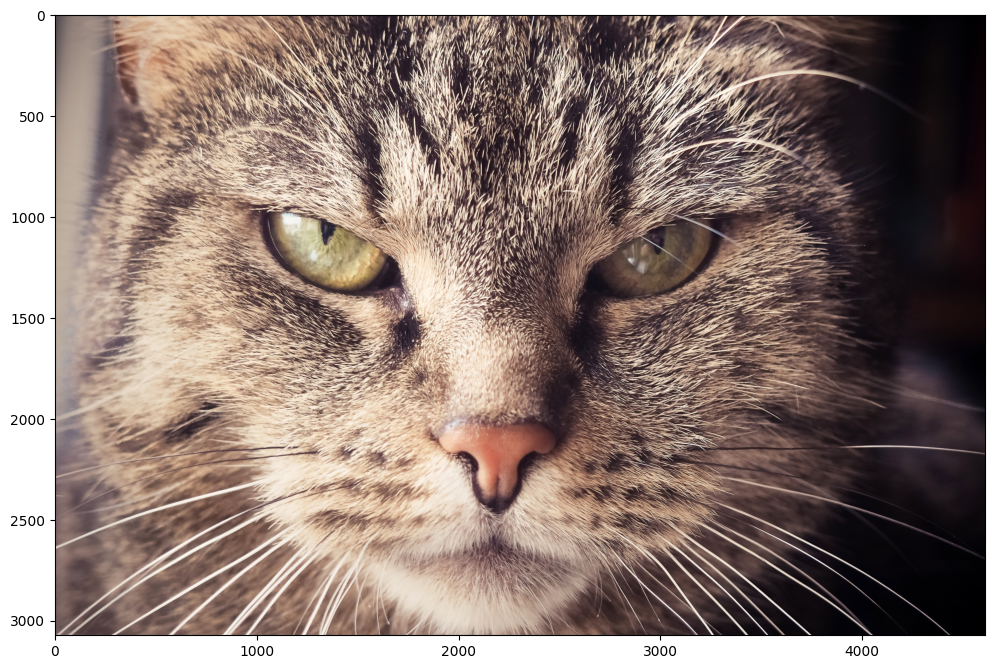

In [29]:
image = img_rgb

h, w, c = image.shape
original_size = (w, h)

plt.figure(figsize=(12, 12))
plt.imshow(image)

In [30]:
new_w = int(w * 0.1)
new_h = int(h * 0.1)
image_resize = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)

image_resize.shape

(307, 460, 3)

In [31]:
pixels = image_resize.reshape(-1, c).astype(np.float32)

pixels

array([[80., 73., 77.],
       [88., 78., 82.],
       [95., 84., 87.],
       ...,
       [ 0.,  0.,  0.],
       [ 0.,  0.,  0.],
       [ 0.,  0.,  0.]], shape=(141220, 3), dtype=float32)

In [32]:
pixels.shape

(141220, 3)

In [34]:
kmeans = KMeans(K=3, max_iters=40)
labels = kmeans.predict(pixels)
centroids = kmeans.cent()

segmented_pixels = centroids[labels.astype(int)]

segmented_resized = segmented_pixels.reshape(new_h, new_w, c).astype(np.uint8)

segmented = cv2.resize(segmented_resized, original_size, interpolation=cv2.INTER_NEAREST)

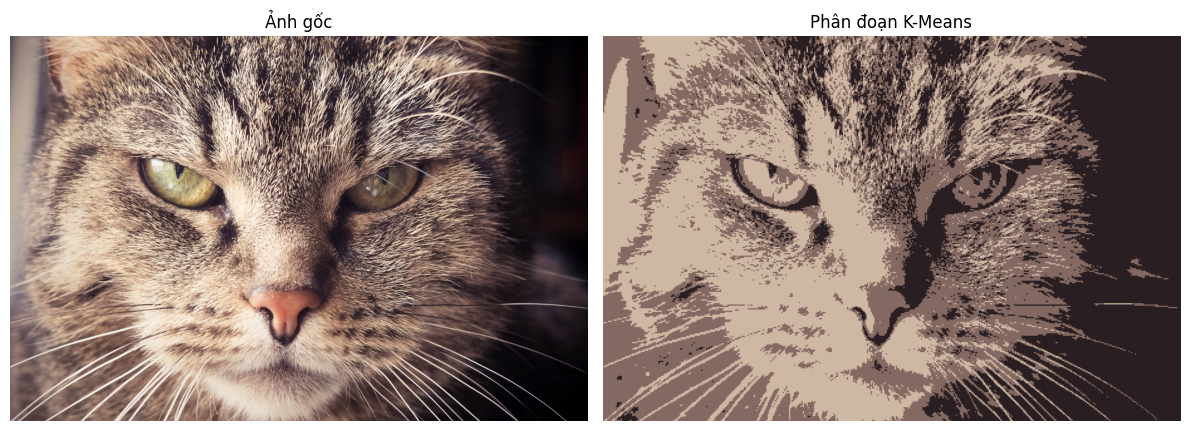

In [35]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Ảnh gốc")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented)
plt.title(f"Phân đoạn K-Means")
plt.axis('off')

plt.tight_layout()
plt.show()